In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

from google.colab import files
uploaded = files.upload()



Saving ABC_Company.csv.csv to ABC_Company.csv (1).csv


In [12]:
df = pd.read_csv("ABC_Company.csv.csv")
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0


In [13]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    object 
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 32.3+ KB


Index(['Name', 'Team', 'Number', 'Position', 'Age', 'Height', 'Weight',
       'College', 'Salary'],
      dtype='object')

#PREPROCESSING
The height column was corrected by replacing values with random numbers between 150 and 180

In [16]:
df.columns = df.columns.str.lower()
df['salary'] = df['salary'].fillna(df['salary'].mean())
df['height'] = np.random.randint(150, 181, size=len(df))
df.columns

Index(['name', 'team', 'number', 'position', 'age', 'height', 'weight',
       'college', 'salary'],
      dtype='object')

#TEAM DISTRIBUTION
Employees are unevenly distributed across teams. Some teams have a higher percentage of employees compared to others.

team
New Orleans Pelicans      4.148472
Memphis Grizzlies         3.930131
Utah Jazz                 3.493450
Milwaukee Bucks           3.493450
New York Knicks           3.493450
Boston Celtics            3.275109
Los Angeles Clippers      3.275109
Los Angeles Lakers        3.275109
Phoenix Suns              3.275109
Sacramento Kings          3.275109
Brooklyn Nets             3.275109
Philadelphia 76ers        3.275109
Toronto Raptors           3.275109
Golden State Warriors     3.275109
Indiana Pacers            3.275109
Detroit Pistons           3.275109
Cleveland Cavaliers       3.275109
Chicago Bulls             3.275109
Houston Rockets           3.275109
San Antonio Spurs         3.275109
Atlanta Hawks             3.275109
Dallas Mavericks          3.275109
Charlotte Hornets         3.275109
Miami Heat                3.275109
Denver Nuggets            3.275109
Washington Wizards        3.275109
Portland Trail Blazers    3.275109
Oklahoma City Thunder     3.275109
Orlando Magic  

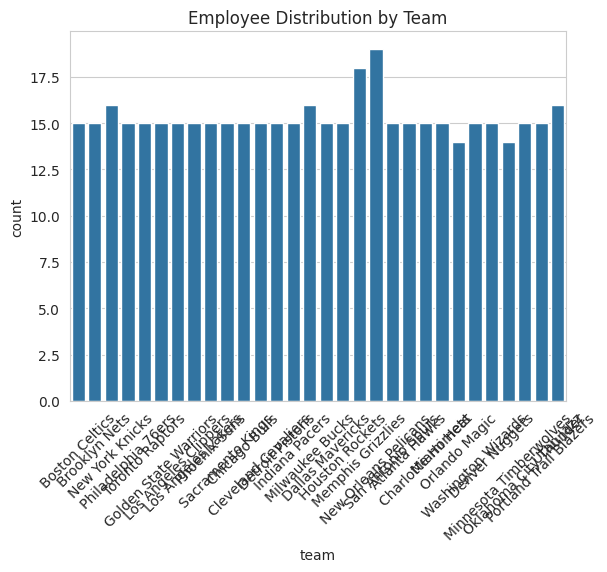

In [17]:
team_count = df['team'].value_counts()
team_percent = (team_count / len(df)) * 100

print(team_percent)

sns.countplot(x='team', data=df)
plt.xticks(rotation=45)
plt.title("Employee Distribution by Team")
plt.show()

#POSITION SEGREGATION

Employees are categorized into different positions. Some positions have more employees, indicating role dominance.

position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


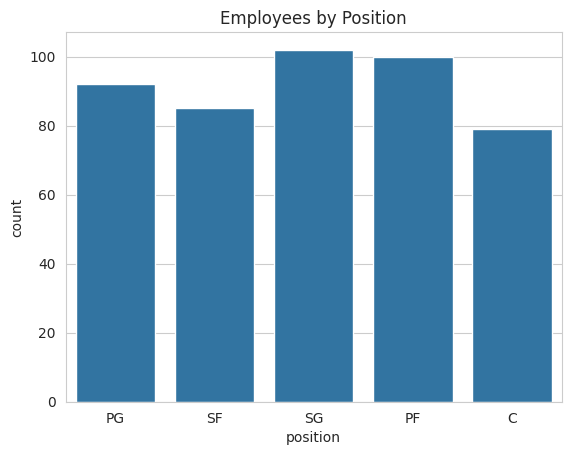

In [18]:
position_count = df['position'].value_counts()
print(position_count)

sns.countplot(x='position', data=df)
plt.title("Employees by Position")
plt.show()

#AGE GROUP

Employees were grouped into age ranges. The 30–40 age group has the highest number of employees.

age_group
20-30    346
30-40     91
40-50      0
50-60      0
Name: count, dtype: int64


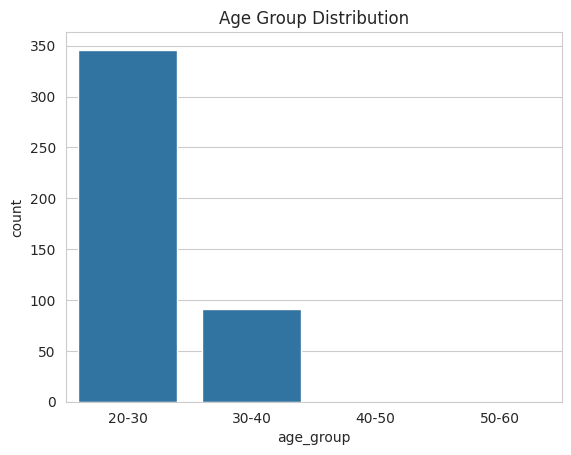

In [19]:
bins = [20, 30, 40, 50, 60]
labels = ['20-30', '30-40', '40-50', '50-60']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

print(df['age_group'].value_counts())

sns.countplot(x='age_group', data=df)
plt.title("Age Group Distribution")
plt.show()

#SALARY EXPENDITURE

Certain teams and positions have the highest salary expenditure, indicating higher workforce size or pay scale.

team
Cleveland Cavaliers       1.118227e+08
Memphis Grizzlies         9.588676e+07
Los Angeles Clippers      9.485464e+07
Oklahoma City Thunder     9.376530e+07
Miami Heat                9.218361e+07
Golden State Warriors     8.886900e+07
Chicago Bulls             8.678338e+07
San Antonio Spurs         8.444273e+07
New Orleans Pelicans      8.275077e+07
Charlotte Hornets         7.834092e+07
Washington Wizards        7.632864e+07
Houston Rockets           7.528302e+07
New York Knicks           7.330390e+07
Atlanta Hawks             7.290295e+07
Los Angeles Lakers        7.177043e+07
Sacramento Kings          7.168367e+07
Dallas Mavericks          7.119873e+07
Toronto Raptors           7.111761e+07
Milwaukee Bucks           6.960352e+07
Detroit Pistons           6.716826e+07
Indiana Pacers            6.675183e+07
Denver Nuggets            6.495590e+07
Minnesota Timberwolves    6.454367e+07
Utah Jazz                 6.400737e+07
Phoenix Suns              6.344514e+07
Boston Celtics      

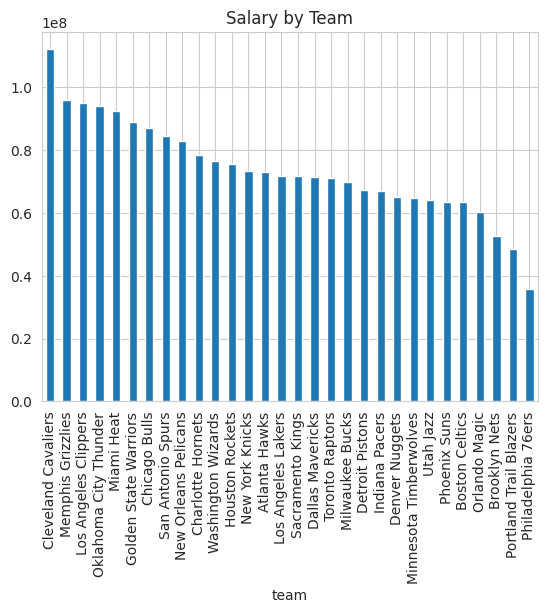

position
C     4.663773e+08
PG    4.661848e+08
PF    4.570628e+08
SF    4.128549e+08
SG    4.114782e+08
Name: salary, dtype: float64


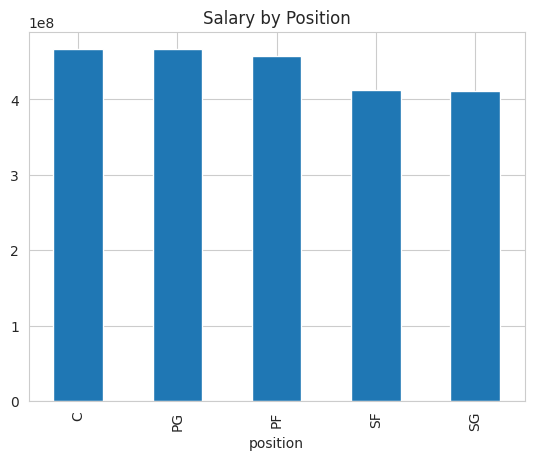

In [20]:
# team
salary_team = df.groupby('team')['salary'].sum().sort_values(ascending=False)
print(salary_team)

salary_team.plot(kind='bar', title="Salary by Team")
plt.show()

# position
salary_position = df.groupby('position')['salary'].sum().sort_values(ascending=False)
print(salary_position)

salary_position.plot(kind='bar', title="Salary by Position")
plt.show()

#CORRELATION

There is a moderate positive correlation between age and salary, indicating that salary increases with experience.

Correlation: 0.21116954917686373


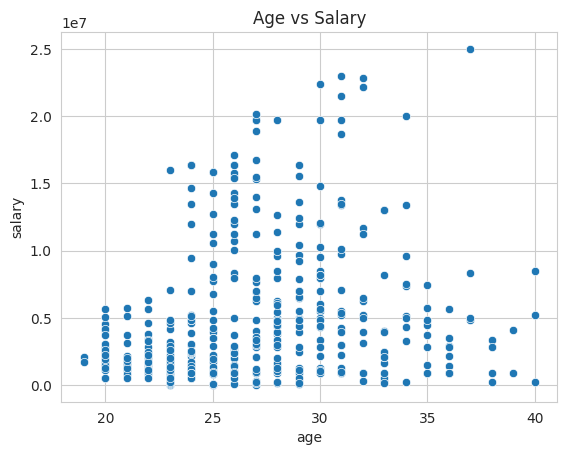

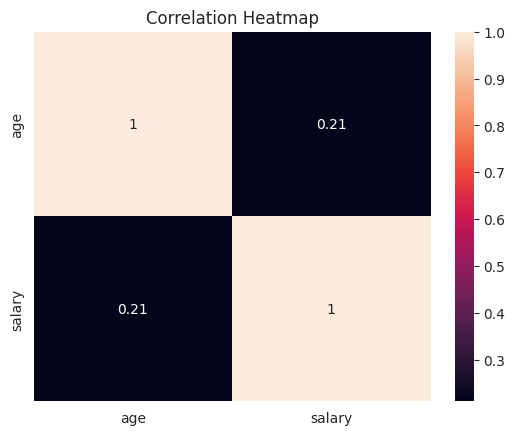

In [21]:
correlation = df['age'].corr(df['salary'])
print("Correlation:", correlation)

sns.scatterplot(x='age', y='salary', data=df)
plt.title("Age vs Salary")
plt.show()

sns.heatmap(df[['age','salary']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

#Datastory


The analysis of the ABC company employee dataset provides meaningful insights into workforce structure and salary distribution.The distribution of employees across the team is uneven,with certain teams having the higher concentration of employees,indicating areas of greater operational focus.


Position-wise analysis shows that while some roles have a larger number of employees, others, particularly senior roles, contribute more significantly to the overall salary expenditure.

The age distribution reveals that most employees fall within the 30–40 age group, suggesting that the organization primarily consists of mid-career professionals.

Salary analysis highlights that specific teams and positions account for the highest expenditure, reflecting either higher pay scales or larger team sizes.

The correlation between age and salary shows a moderate positive relationship, indicating that experience plays a role in determining employee earnings.

Overall, the company demonstrates a structured workforce with a focus on experienced employees and strategic allocation of salary resources.